# Optimization Graphs

This notebook builds optimization-oriented visuals from Damm logistics data.

## Visuals
1. Route compactness map per `Ruta` with convex hull and spread metrics.
2. Stop sequence sanity chart (distance between consecutive stops).
3. Client demand volatility heatmap (`client x weekday`).
4. SKU co-occurrence network from `Entrega` baskets.
5. Warehouse pick-path proxy from `Ubic` transitions.
6. Route load profile over stops (deliveries vs returnables).
7. Time-window pressure chart by route/day.
8. Pareto frontier chart (distance vs handling cost).
9. Top difficult stops ranking.
10. Route-level KPI scatter.

Assumption used in multiple charts: row order in `Detalle_entrega.csv` approximates historical stop sequence within each transport.

In [1]:
from __future__ import annotations

import math
import re
from collections import Counter
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 60)

DEPOT_LAT = 41.55
DEPOT_LON = 2.21
EARTH_RADIUS_KM = 6371.0088


def resolve_first_existing(paths: list[Path]) -> Path:
    for p in paths:
        if p.exists():
            return p
    raise FileNotFoundError("Could not find any expected input file path.")


def normalize_text(value: object) -> str:
    if pd.isna(value):
        return ""
    text = str(value).strip().lower()
    text = re.sub(r"\s+", " ", text)
    return text


def normalize_client_code(value: object) -> str:
    if pd.isna(value):
        return ""
    digits = re.sub(r"\D", "", str(value))
    return digits.lstrip("0")


def build_address_query(calle: object, cp: object, poblacion: object) -> str:
    cp_digits = re.sub(r"\D", "", str(cp)) if not pd.isna(cp) else ""
    cp_digits = cp_digits.zfill(5) if cp_digits else ""
    parts = [str(calle).strip() if not pd.isna(calle) else "", " ".join([cp_digits, str(poblacion).strip() if not pd.isna(poblacion) else ""]).strip(), "Spain"]
    return ", ".join([p for p in parts if p])


def haversine_km(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
    return 2 * EARTH_RADIUS_KM * math.asin(math.sqrt(a))


def convex_hull(points: list[tuple[float, float]]) -> list[tuple[float, float]]:
    # Andrew monotone chain on (x=lon, y=lat)
    pts = sorted(set(points))
    if len(pts) <= 2:
        return pts

    def cross(o, a, b):
        return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])

    lower = []
    for p in pts:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(p)

    upper = []
    for p in reversed(pts):
        while len(upper) >= 2 and cross(upper[-2], upper[-1], p) <= 0:
            upper.pop()
        upper.append(p)

    return lower[:-1] + upper[:-1]


def polygon_area(points: list[tuple[float, float]]) -> float:
    # Shoelace in degree-space (relative metric only for ranking spread)
    if len(points) < 3:
        return 0.0
    area = 0.0
    for i in range(len(points)):
        x1, y1 = points[i]
        x2, y2 = points[(i + 1) % len(points)]
        area += x1 * y2 - x2 * y1
    return abs(area) / 2


def pareto_front(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    # Lower x and lower y are better.
    ordered = df.sort_values([x_col, y_col]).reset_index(drop=True)
    best_y = float("inf")
    keep = []
    for _, row in ordered.iterrows():
        if row[y_col] <= best_y:
            keep.append(True)
            best_y = row[y_col]
        else:
            keep.append(False)
    return ordered.loc[keep].copy()

In [2]:
# Data loading and reusable prep layer
root = Path("..")

paths = {
    "detalle": resolve_first_existing([
        root / "data/csv/Hackaton/Detalle_entrega.csv",
        Path("data/csv/Hackaton/Detalle_entrega.csv"),
    ]),
    "geo": resolve_first_existing([
        root / "data/custom/geo/geocoded_direcciones.csv",
        root / "data/geocoded_direcciones.csv",
        Path("data/custom/geo/geocoded_direcciones.csv"),
        Path("data/geocoded_direcciones.csv"),
    ]),
    "horarios": resolve_first_existing([
        root / "data/csv/Horarios_Entrega/Sheet1.csv",
        Path("data/csv/Horarios_Entrega/Sheet1.csv"),
    ]),
    "zubic": resolve_first_existing([
        root / "data/csv/Hackaton/Materiales_zubic.csv",
        Path("data/csv/Hackaton/Materiales_zubic.csv"),
    ]),
}

raw_detalle = pd.read_csv(paths["detalle"], low_memory=False)
raw_geo = pd.read_csv(paths["geo"], engine="python", on_bad_lines="skip")
raw_horarios = pd.read_csv(paths["horarios"], low_memory=False)
raw_zubic = pd.read_csv(paths["zubic"], low_memory=False)

# Normalize Detalle
detalle = raw_detalle.copy()
detalle = detalle.rename(columns={"ZonaTransp": "ZonaTranspCod", "ZonaTransp": "ZonaTranspCod"})
detalle["row_id"] = np.arange(len(detalle))
detalle["FECHA_dt"] = pd.to_datetime(detalle["FECHA"], dayfirst=True, errors="coerce")
detalle["qty"] = pd.to_numeric(detalle["Cantidad entrega"], errors="coerce").fillna(0.0)
detalle["client_code"] = detalle["Destinatario mcía..1"].map(normalize_client_code)
detalle["client_name_norm"] = detalle["Nombre 1"].map(normalize_text)
detalle["address_query"] = detalle.apply(
    lambda r: build_address_query(r.get("Calle"), r.get("CP"), r.get("Población")),
    axis=1,
)
detalle["address_query_norm"] = detalle["address_query"].map(normalize_text)
detalle["material"] = detalle["Material"].astype(str)

detalle["is_returnable"] = (
    detalle["material"].str.startswith(("CJ", "3ENV", "BRL"))
    | detalle["material"].str.endswith("V")
)

# Geocodes
geo = raw_geo.copy()
geo["lat"] = pd.to_numeric(geo["lat"], errors="coerce")
geo["lon"] = pd.to_numeric(geo["lon"], errors="coerce")
geo["query_norm"] = geo["query"].map(normalize_text)
geo = geo.dropna(subset=["lat", "lon"])
geo = geo.drop_duplicates(subset=["query_norm", "lat", "lon"])

# Join coordinates by normalized address query
detalle = detalle.merge(
    geo[["query_norm", "lat", "lon"]],
    how="left",
    left_on="address_query_norm",
    right_on="query_norm",
)

detalle["lat"] = pd.to_numeric(detalle["lat"], errors="coerce")
detalle["lon"] = pd.to_numeric(detalle["lon"], errors="coerce")

# Delivery-level view (one row per Entrega)
detalle["qty_outbound_line"] = np.where(detalle["is_returnable"], 0.0, detalle["qty"])
detalle["qty_returnable_line"] = np.where(detalle["is_returnable"], detalle["qty"], 0.0)

stop_df = (
    detalle.sort_values("row_id")
    .groupby(["Transporte", "Entrega"], as_index=False)
    .agg(
        FECHA_dt=("FECHA_dt", "first"),
        Ruta=("Ruta", "first"),
        client_code=("client_code", "first"),
        client_name=("Nombre 1", "first"),
        client_name_norm=("client_name_norm", "first"),
        poblacion=("Población", "first"),
        lat=("lat", "first"),
        lon=("lon", "first"),
        row_id=("row_id", "min"),
        qty_outbound=("qty_outbound_line", "sum"),
        qty_returnable=("qty_returnable_line", "sum"),
        sku_count=("material", "nunique"),
        umv_variety=("Un.medida venta", "nunique"),
        line_count=("material", "size"),
        returnable_lines=("is_returnable", "sum"),
    )
)
stop_df["returnable_share"] = (stop_df["returnable_lines"] / stop_df["line_count"]).fillna(0.0)
stop_df["weekday_name"] = stop_df["FECHA_dt"].dt.day_name()
stop_df["weekday_num"] = stop_df["FECHA_dt"].dt.weekday + 1

# Transport sequence derived from row order
stop_df = stop_df.sort_values(["Transporte", "row_id"]).copy()
stop_df["stop_order"] = stop_df.groupby("Transporte").cumcount() + 1

# Material location map
zubic = raw_zubic[["Material", "Ubic."]].drop_duplicates().copy()
zubic["material"] = zubic["Material"].astype(str)

# Extract aisle bucket (AA/AB/CB/...) for transition proxies
def extract_aisle_bucket(ubic: object) -> str:
    if pd.isna(ubic):
        return "UNKNOWN"
    text = str(ubic).strip().upper()
    m = re.match(r"^([A-Z]{2})", text)
    if m:
        return m.group(1)
    if text in {"ZCG", "A0DISTRIDA", "PLV", "ENVASE", "AAAAAA"}:
        return text
    return "OTHER"

zubic["aisle_bucket"] = zubic["Ubic."].map(extract_aisle_bucket)

detalle = detalle.merge(zubic[["material", "Ubic.", "aisle_bucket"]], on="material", how="left")

# Horarios normalization
horarios = raw_horarios.copy()
horarios["deudor_norm"] = horarios["Deudor"].map(normalize_client_code)
horarios["client_name_norm"] = horarios["Nombre 1"].map(normalize_text)
horarios["weekday_num"] = pd.to_numeric(horarios["Día semana"], errors="coerce")
horarios["start_td"] = pd.to_timedelta(horarios["Horario inicia a"].astype(str), errors="coerce")
horarios["end_td"] = pd.to_timedelta(horarios["Horario termina a"].astype(str), errors="coerce")
horarios["window_hours_raw"] = (horarios["end_td"] - horarios["start_td"]).dt.total_seconds() / 3600
horarios["window_hours"] = horarios["window_hours_raw"].clip(lower=0).fillna(0)
horarios["is_closed"] = horarios["Cierre Si/No"].astype(str).str.strip().str.upper().eq("X")

# Use name match first and fallback to code when possible
schedule_join = stop_df.merge(
    horarios[["client_name_norm", "deudor_norm", "weekday_num", "window_hours", "is_closed"]],
    on=["client_name_norm", "weekday_num"],
    how="left",
)

# Coverage diagnostics
geo_coverage = stop_df[["lat", "lon"]].notna().all(axis=1).mean()
schedule_coverage = schedule_join["window_hours"].notna().mean()

print("Input files:")
for k, v in paths.items():
    print(f"- {k}: {v}")
print()
print(f"Detalle rows: {len(detalle):,}")
print(f"Stops (Entrega-level): {len(stop_df):,}")
print(f"Geocode coverage at stop-level: {geo_coverage:.2%}")
print(f"Schedule coverage at stop-level: {schedule_coverage:.2%}")
print("Returnable classification: material prefix CJ/3ENV/BRL or suffix V")

Input files:
- detalle: ../data/csv/Hackaton/Detalle_entrega.csv
- geo: ../data/custom/geo/geocoded_direcciones.csv
- horarios: ../data/csv/Horarios_Entrega/Sheet1.csv
- zubic: ../data/csv/Hackaton/Materiales_zubic.csv

Detalle rows: 82,849
Stops (Entrega-level): 8,927
Geocode coverage at stop-level: 98.43%
Schedule coverage at stop-level: 12.96%
Returnable classification: material prefix CJ/3ENV/BRL or suffix V


## 1) Route compactness map (per Ruta)

Visual diagnostic to identify geographically dispersed routes that are strong candidates for re-zoning.

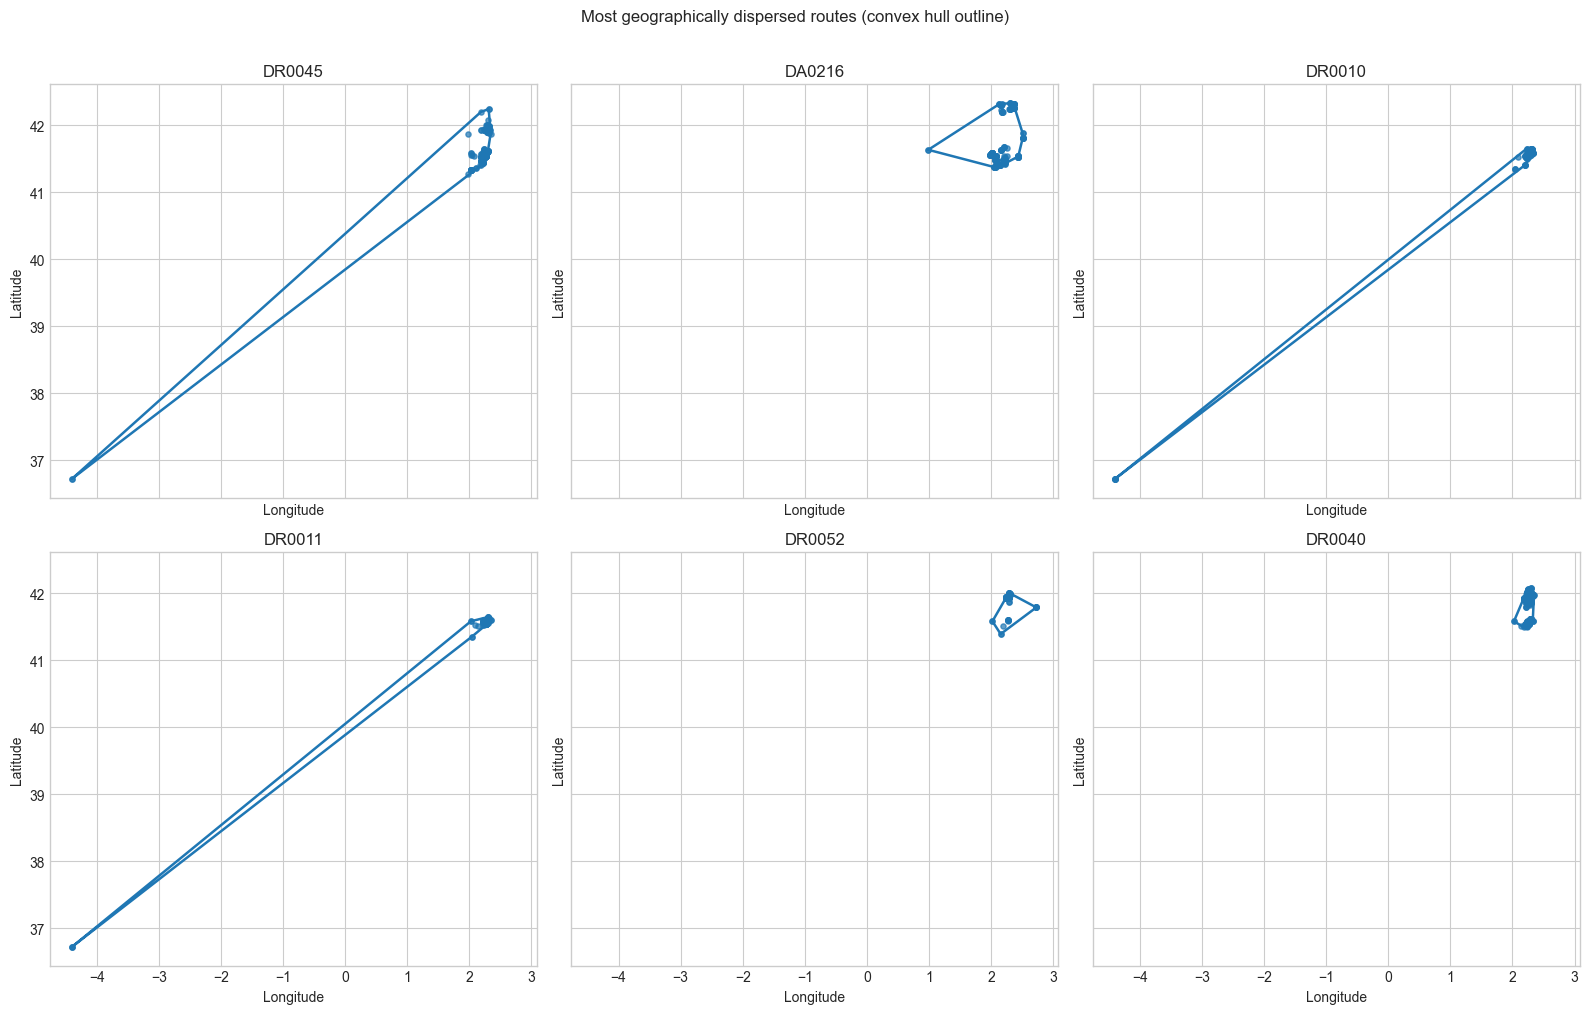

Top routes by compactness_score (higher = more dispersed):


,Ruta,n_stops,hull_area_deg2,spread_km_mean_to_centroid,compactness_score
13,DR0045,333,2.733071,18.652054,50.977405
0,DA0216,261,0.825165,30.284193,24.989493
3,DR0010,619,0.763854,15.866074,12.119378
4,DR0011,491,0.824699,10.389293,8.568054
16,DR0052,68,0.204056,16.974209,3.463701
12,DR0040,484,0.111577,17.439721,1.945892
11,DR0038,493,0.118991,16.037760,1.908363
5,DR0016,684,0.568263,3.275889,1.861569
8,DR0027,425,0.094766,19.017335,1.802218
10,DR0032,483,0.445810,3.905184,1.740974


Interpretation: prioritize top-ranked dispersed routes for route zoning review.


In [3]:
route_points = (
    stop_df.dropna(subset=["lat", "lon"])
    .groupby("Ruta")
    .agg(
        n_stops=("Entrega", "count"),
        n_clients=("client_code", "nunique"),
        mean_lat=("lat", "mean"),
        mean_lon=("lon", "mean"),
    )
    .reset_index()
)

metrics = []
for ruta, g in stop_df.dropna(subset=["lat", "lon"]).groupby("Ruta"):
    pts = list(zip(g["lon"].tolist(), g["lat"].tolist()))
    hull = convex_hull(pts)
    hull_area = polygon_area(hull)
    centroid_lat = g["lat"].mean()
    centroid_lon = g["lon"].mean()
    spread_km = np.mean([haversine_km(lat, lon, centroid_lat, centroid_lon) for lat, lon in zip(g["lat"], g["lon"])])
    metrics.append(
        {
            "Ruta": ruta,
            "n_stops": len(g),
            "hull_area_deg2": hull_area,
            "spread_km_mean_to_centroid": spread_km,
            "compactness_score": (spread_km * (hull_area + 1e-6)),
            "hull": hull,
        }
    )

route_compactness = pd.DataFrame(metrics).sort_values("compactness_score", ascending=False)

plot_routes = route_compactness["Ruta"].head(6).tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, ruta in zip(axes, plot_routes):
    g = stop_df[(stop_df["Ruta"] == ruta) & stop_df["lat"].notna() & stop_df["lon"].notna()]
    ax.scatter(g["lon"], g["lat"], s=14, alpha=0.7)
    hull = route_compactness.loc[route_compactness["Ruta"] == ruta, "hull"].iloc[0]
    if len(hull) >= 3:
        hx, hy = zip(*(hull + [hull[0]]))
        ax.plot(hx, hy, linewidth=1.8)
    ax.set_title(ruta)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

for i in range(len(plot_routes), len(axes)):
    axes[i].axis("off")

fig.suptitle("Most geographically dispersed routes (convex hull outline)", y=1.01)
plt.tight_layout()
plt.show()

print("Top routes by compactness_score (higher = more dispersed):")
display(route_compactness[["Ruta", "n_stops", "hull_area_deg2", "spread_km_mean_to_centroid", "compactness_score"]].head(10))
print("Interpretation: prioritize top-ranked dispersed routes for route zoning review.")

## 2) Stop sequence sanity chart (jump distances)

Large jump distances between consecutive stops suggest route friction or sequence inefficiencies.

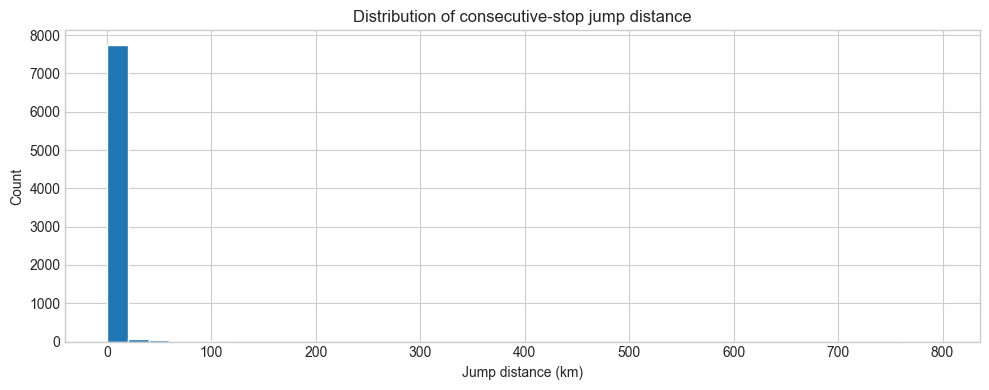

Transports with largest jump spikes (route friction candidates):


,Transporte,avg_jump_km,p90_jump_km,max_jump_km,n_jumps
225,11491390,177.621662,793.772231,795.607654,9
334,11515121,111.791679,792.786871,793.098775,31
472,11557138,212.366572,792.680627,793.709185,15
317,11511105,217.037201,791.539143,793.098775,11
637,11608995,145.416947,757.088421,793.074931,11
62,11438717,118.299924,567.872581,795.607654,14
545,11583077,114.903840,541.106473,793.074931,14
390,11534285,105.691134,415.435070,795.607654,16
140,11465571,98.048376,340.199756,796.048184,17
672,11618145,75.526342,179.657569,582.093969,8


Interpretation: investigate top transports for sequence redesign or zone boundary issues.


In [4]:
seq_rows = []
for transport, g in stop_df.dropna(subset=["lat", "lon"]).sort_values(["Transporte", "stop_order"]).groupby("Transporte"):
    g = g.sort_values("stop_order")
    prev = None
    for _, row in g.iterrows():
        if prev is not None:
            jump_km = haversine_km(prev["lat"], prev["lon"], row["lat"], row["lon"])
            seq_rows.append(
                {
                    "Transporte": transport,
                    "Ruta": row["Ruta"],
                    "stop_order": int(row["stop_order"]),
                    "jump_km": jump_km,
                }
            )
        prev = row

jumps = pd.DataFrame(seq_rows)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(jumps["jump_km"], bins=40, color="#1f77b4", edgecolor="white")
ax.set_title("Distribution of consecutive-stop jump distance")
ax.set_xlabel("Jump distance (km)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

transport_jump = jumps.groupby("Transporte").agg(
    avg_jump_km=("jump_km", "mean"),
    p90_jump_km=("jump_km", lambda s: np.percentile(s, 90)),
    max_jump_km=("jump_km", "max"),
    n_jumps=("jump_km", "size"),
).reset_index()

worst = transport_jump.sort_values(["p90_jump_km", "max_jump_km"], ascending=False).head(10)
print("Transports with largest jump spikes (route friction candidates):")
display(worst)
print("Interpretation: investigate top transports for sequence redesign or zone boundary issues.")

## 3) Client demand volatility heatmap (`client x weekday`)

Shows delivery stability by weekday for top clients.

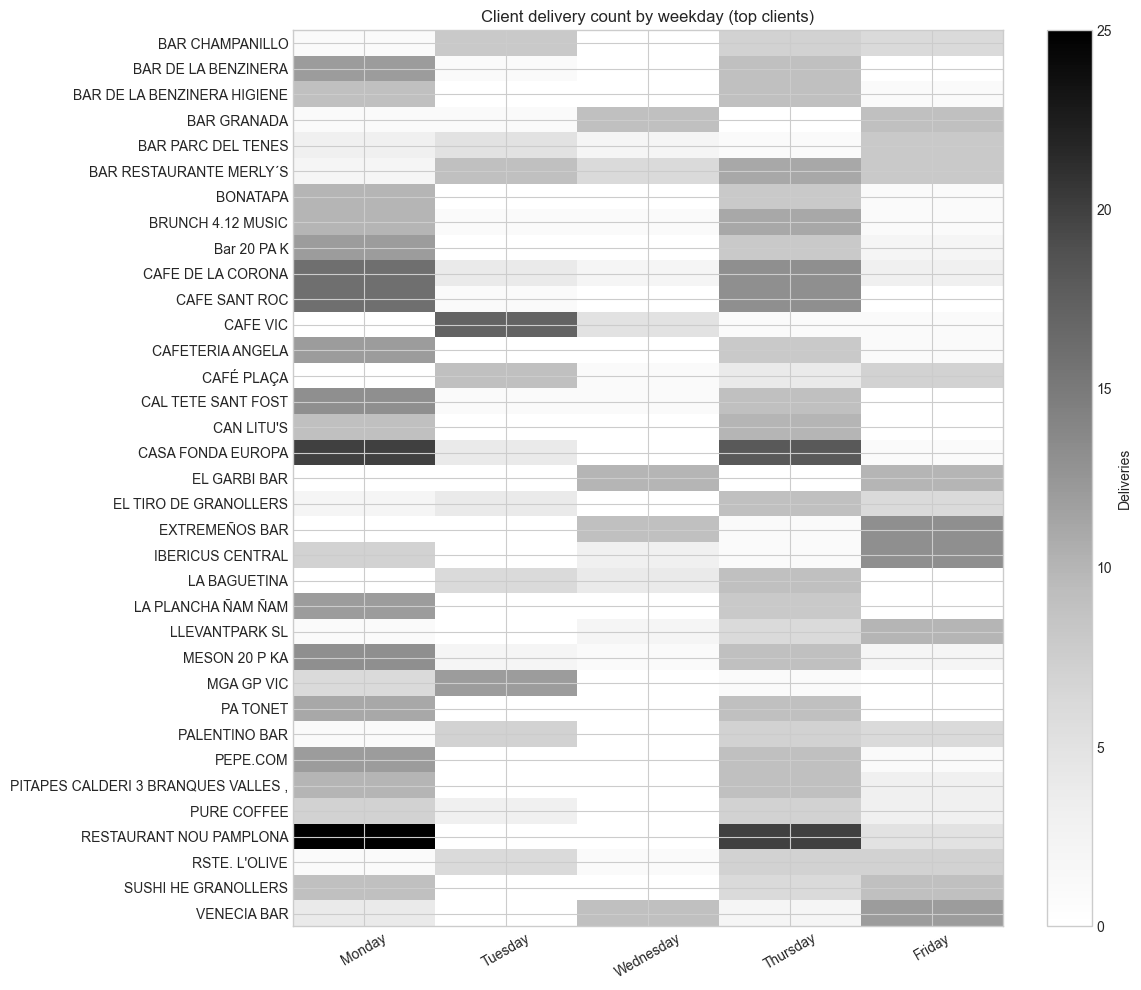

Most volatile clients by weekday delivery pattern:


,cv_delivery_count
client_name,
CAFE VIC,1.476082
LA PLANCHA ÑAM ÑAM,1.414214
PA TONET,1.380670
CAN LITU'S,1.372464
MGA GP VIC,1.372464
EL GARBI BAR,1.369306
EXTREMEÑOS BAR,1.309771
CAFETERIA ANGELA,1.308441
CAFE SANT ROC,1.307032


Interpretation: low-volatility clients are strong candidates for fixed anchor planning.


In [5]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

client_day = (
    stop_df.groupby(["client_code", "client_name", "weekday_name"])
    .agg(delivery_count=("Entrega", "count"), qty_total=("qty_outbound", "sum"))
    .reset_index()
)

top_clients = (
    stop_df.groupby(["client_code", "client_name"])['Entrega']
    .count()
    .sort_values(ascending=False)
    .head(35)
    .reset_index()["client_code"]
)

heat = client_day[client_day["client_code"].isin(top_clients)].copy()
heat["weekday_name"] = pd.Categorical(heat["weekday_name"], categories=weekday_order, ordered=True)
heat = heat.sort_values("weekday_name")

pivot = heat.pivot_table(index="client_name", columns="weekday_name", values="delivery_count", fill_value=0)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(pivot.values, aspect="auto")
ax.set_title("Client delivery count by weekday (top clients)")
ax.set_xticks(np.arange(len(pivot.columns)), labels=pivot.columns, rotation=30)
ax.set_yticks(np.arange(len(pivot.index)), labels=pivot.index)
fig.colorbar(im, ax=ax, label="Deliveries")
plt.tight_layout()
plt.show()

volatility = (
    pivot.std(axis=1) / (pivot.mean(axis=1).replace(0, np.nan))
).replace([np.inf, -np.inf], np.nan).fillna(0)
print("Most volatile clients by weekday delivery pattern:")
display(volatility.sort_values(ascending=False).head(12).to_frame("cv_delivery_count"))
print("Interpretation: low-volatility clients are strong candidates for fixed anchor planning.")

## 4) SKU co-occurrence network

Pairs of materials frequently appearing in the same delivery can inform pallet grouping or pick-bundle design.

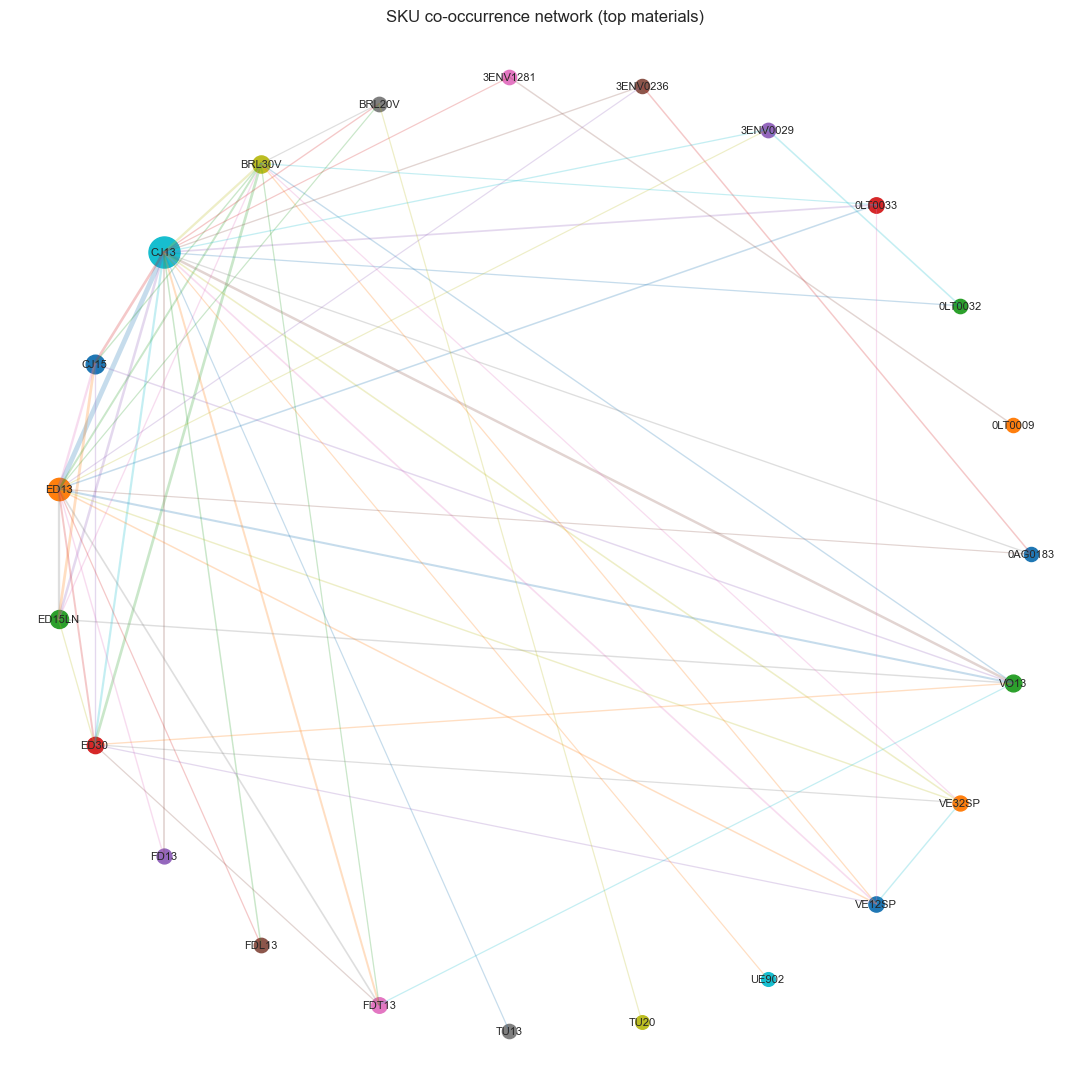

Top co-occurring SKU pairs:


,a,b,count
5,CJ13,ED13,4022
20,CJ15,ED15LN,1967
19,BRL30V,ED30,1922
43,CJ13,CJ15,1848
44,CJ13,ED15LN,1762
53,CJ13,VO13,1737
46,CJ15,ED13,1594
48,ED13,ED15LN,1538
23,BRL30V,CJ13,1536
26,CJ13,ED30,1471


Interpretation: thick links indicate candidates for co-picking and pallet adjacency rules.


In [6]:
# Build delivery baskets
basket = (
    detalle.groupby("Entrega")["material"]
    .apply(lambda s: sorted(set(s)))
)

material_freq = detalle["material"].value_counts()
core_materials = set(material_freq.head(30).index)

pair_counter = Counter()
for mats in basket:
    mats = [m for m in mats if m in core_materials]
    for a, b in combinations(mats, 2):
        pair_counter[(a, b)] += 1

pair_df = pd.DataFrame([
    {"a": a, "b": b, "count": c}
    for (a, b), c in pair_counter.items()
]).sort_values("count", ascending=False)

top_edges = pair_df.head(60).copy()
nodes = sorted(set(top_edges["a"]).union(set(top_edges["b"])))

# Circular layout without external graph dependencies
angles = np.linspace(0, 2 * np.pi, len(nodes), endpoint=False)
node_pos = {n: (np.cos(t), np.sin(t)) for n, t in zip(nodes, angles)}

fig, ax = plt.subplots(figsize=(11, 11))
max_count = max(top_edges["count"].max(), 1)
for _, e in top_edges.iterrows():
    x1, y1 = node_pos[e["a"]]
    x2, y2 = node_pos[e["b"]]
    w = 0.5 + 3.0 * (e["count"] / max_count)
    ax.plot([x1, x2], [y1, y2], linewidth=w, alpha=0.25)

for n in nodes:
    x, y = node_pos[n]
    size = 80 + 420 * (material_freq.get(n, 0) / material_freq.head(30).max())
    ax.scatter([x], [y], s=size)
    ax.text(x, y, n, fontsize=8, ha="center", va="center")

ax.set_title("SKU co-occurrence network (top materials)")
ax.axis("off")
plt.tight_layout()
plt.show()

print("Top co-occurring SKU pairs:")
display(top_edges.head(15))
print("Interpretation: thick links indicate candidates for co-picking and pallet adjacency rules.")

## 5) Warehouse pick-path proxy (`Ubic` transitions)

Transition frequency between aisle buckets approximates where picker flow concentrates.

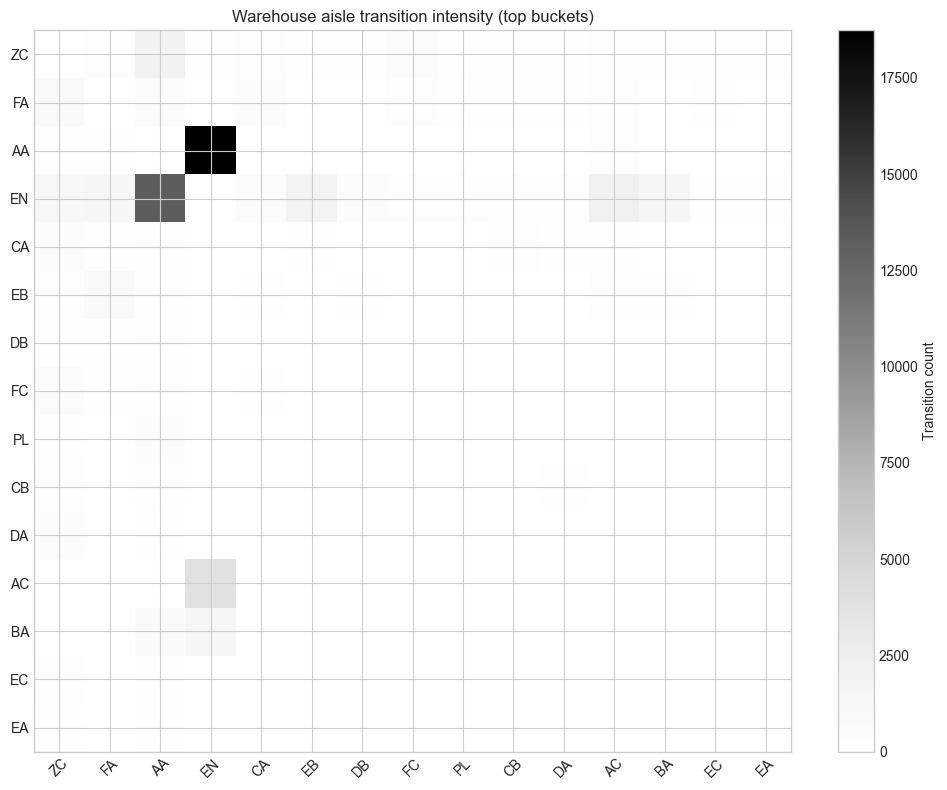

Top aisle transitions:


,from,to,count
10,AA,EN,18733
11,EN,AA,13228
17,AC,EN,3813
16,EN,AC,2253
15,ZC,AA,2039
18,EN,EB,1771
44,EN,FA,1458
12,EN,BA,1402
23,BA,EN,1389
21,EN,ZC,1268


Interpretation: dominant transitions identify high-traffic aisle links to target staging redesign.


In [7]:
loc_lines = detalle.dropna(subset=["aisle_bucket"]).sort_values(["Transporte", "row_id"])

transition_counter = Counter()
for transport, g in loc_lines.groupby("Transporte"):
    seq = g["aisle_bucket"].tolist()
    for a, b in zip(seq[:-1], seq[1:]):
        if a != b:
            transition_counter[(a, b)] += 1

transitions = pd.DataFrame(
    [{"from": k[0], "to": k[1], "count": v} for k, v in transition_counter.items()]
).sort_values("count", ascending=False)

top_buckets = pd.Index(
    transitions.head(120)[["from", "to"]].stack().value_counts().head(15).index
)
mat = pd.DataFrame(0, index=top_buckets, columns=top_buckets)
for _, r in transitions.iterrows():
    if r["from"] in mat.index and r["to"] in mat.columns:
        mat.loc[r["from"], r["to"]] += int(r["count"])

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(mat.values, aspect="auto")
ax.set_title("Warehouse aisle transition intensity (top buckets)")
ax.set_xticks(np.arange(len(mat.columns)), labels=mat.columns, rotation=45)
ax.set_yticks(np.arange(len(mat.index)), labels=mat.index)
fig.colorbar(im, ax=ax, label="Transition count")
plt.tight_layout()
plt.show()

print("Top aisle transitions:")
display(transitions.head(20))
print("Interpretation: dominant transitions identify high-traffic aisle links to target staging redesign.")

## 6) Route load profile over stops (deliveries vs returnables)

Simulates load evolution using outbound and returnable quantities per stop.

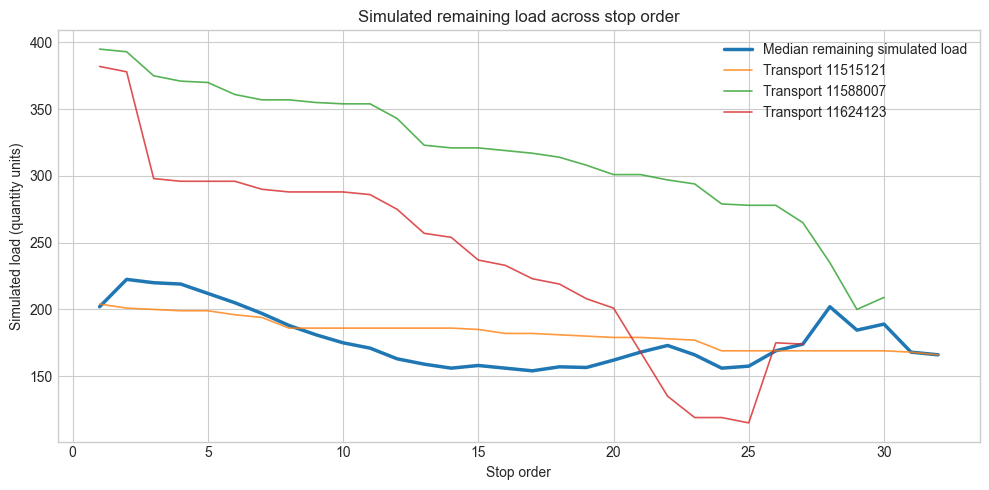

Total outbound vs returnable quantity used in simulation:
qty_outbound      209873.0
qty_returnable     79922.0
Interpretation: flatter decay indicates strong returnable offset and potential capacity persistence during route.


In [8]:
profiles = []
for transport, g in stop_df.sort_values(["Transporte", "stop_order"]).groupby("Transporte"):
    g = g.copy()
    total_outbound = g["qty_outbound"].sum()
    current_load = total_outbound
    for _, row in g.iterrows():
        current_load = current_load - row["qty_outbound"] + row["qty_returnable"]
        profiles.append(
            {
                "Transporte": transport,
                "Ruta": row["Ruta"],
                "stop_order": int(row["stop_order"]),
                "relative_position": row["stop_order"] / max(g["stop_order"]),
                "remaining_load_sim": current_load,
                "qty_outbound": row["qty_outbound"],
                "qty_returnable": row["qty_returnable"],
            }
        )

profile_df = pd.DataFrame(profiles)

fig, ax = plt.subplots(figsize=(10, 5))
median_curve = profile_df.groupby("stop_order")["remaining_load_sim"].median()
ax.plot(median_curve.index, median_curve.values, linewidth=2.5, label="Median remaining simulated load")

sample_transports = profile_df.groupby("Transporte")["stop_order"].max().sort_values(ascending=False).head(3).index
for t in sample_transports:
    s = profile_df[profile_df["Transporte"] == t]
    ax.plot(s["stop_order"], s["remaining_load_sim"], alpha=0.8, linewidth=1.2, label=f"Transport {t}")

ax.set_title("Simulated remaining load across stop order")
ax.set_xlabel("Stop order")
ax.set_ylabel("Simulated load (quantity units)")
ax.legend()
plt.tight_layout()
plt.show()

balance = profile_df[["qty_outbound", "qty_returnable"]].sum()
print("Total outbound vs returnable quantity used in simulation:")
print(balance.to_string())
print("Interpretation: flatter decay indicates strong returnable offset and potential capacity persistence during route.")

## 7) Time-window pressure chart

Window tightness is computed for stops with matched schedule records.

In [9]:
sched = schedule_join.copy()
sched["window_hours"] = pd.to_numeric(sched["window_hours"], errors="coerce")
sched = sched[~sched["is_closed"].fillna(False)]

# Pressure proxy: narrower windows imply higher pressure.
sched["window_hours_capped"] = sched["window_hours"].clip(lower=0, upper=24)
sched["pressure_score"] = 1 - (sched["window_hours_capped"] / 24.0)

pressure = (
    sched.dropna(subset=["window_hours_capped"])
    .groupby(["Ruta", "weekday_name"])
    .agg(
        matched_stops=("Entrega", "count"),
        avg_window_hours=("window_hours_capped", "mean"),
        avg_pressure=("pressure_score", "mean"),
    )
    .reset_index()
)

pivot_pressure = pressure.pivot_table(index="Ruta", columns="weekday_name", values="avg_pressure", fill_value=np.nan)
pivot_pressure = pivot_pressure.reindex(columns=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(pivot_pressure.values, aspect="auto", vmin=0, vmax=1)
ax.set_title("Time-window pressure by route and weekday (0=wide, 1=tight)")
ax.set_xticks(np.arange(len(pivot_pressure.columns)), labels=pivot_pressure.columns, rotation=30)
ax.set_yticks(np.arange(len(pivot_pressure.index)), labels=pivot_pressure.index)
fig.colorbar(im, ax=ax, label="Average pressure score")
plt.tight_layout()
plt.show()

print("Coverage summary for time-window analysis:")
print(f"Stops with matched schedules: {sched['window_hours'].notna().sum():,} / {len(stop_df):,}")
print("Interpretation: prioritize high-pressure route/day cells when evaluating VRPTW feasibility.")

KeyError: "None of [Index([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1,\n       ...\n       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],\n      dtype='object', length=9014)] are in the [columns]"

## 8) Pareto frontier (distance vs handling cost)

Candidate plans are heuristic sequence alternatives per transport for comparison, not a full optimizer output.

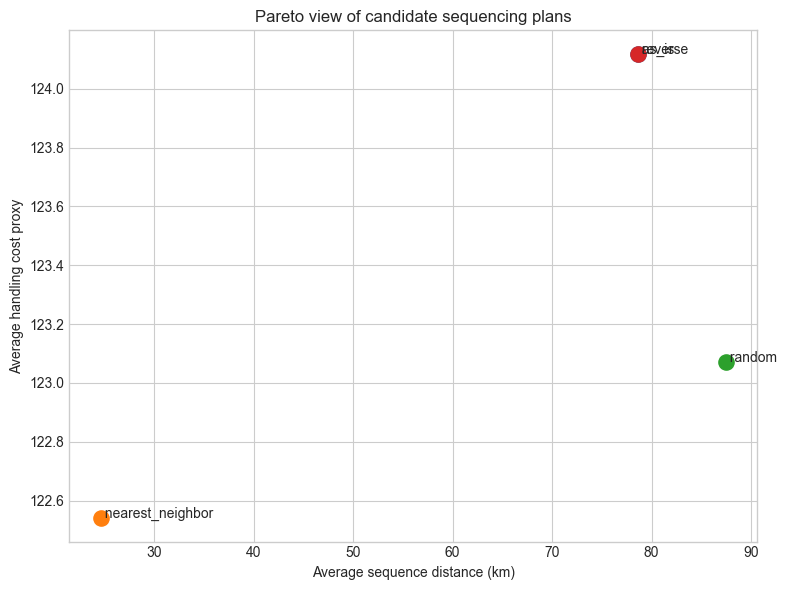

Candidate plan summary:


,plan,distance_km,handling_cost
1,nearest_neighbor,24.589927,122.539337
0,as_is,78.649928,124.119376
3,reverse,78.649928,124.119376
2,random,87.483647,123.069414


Interpretation: plans on Pareto frontier represent better distance-handling trade-offs.


In [ ]:
stop_bucket_span = (
    detalle.groupby(["Transporte", "Entrega"])["aisle_bucket"]
    .nunique()
    .rename("bucket_span")
    .reset_index()
)

pareto_base = stop_df.merge(stop_bucket_span, on=["Transporte", "Entrega"], how="left")
pareto_base["bucket_span"] = pareto_base["bucket_span"].fillna(1)

def sequence_distance_km(g: pd.DataFrame) -> float:
    total = 0.0
    for i in range(1, len(g)):
        total += haversine_km(g.iloc[i - 1]["lat"], g.iloc[i - 1]["lon"], g.iloc[i]["lat"], g.iloc[i]["lon"])
    return total


def nearest_neighbor_order(g: pd.DataFrame) -> pd.DataFrame:
    remaining = g.copy()
    ordered_rows = []
    current = remaining.iloc[0]
    ordered_rows.append(current)
    remaining = remaining.iloc[1:].copy()
    while not remaining.empty:
        d = remaining.apply(lambda r: haversine_km(current["lat"], current["lon"], r["lat"], r["lon"]), axis=1)
        idx = d.idxmin()
        current = remaining.loc[idx]
        ordered_rows.append(current)
        remaining = remaining.drop(index=idx)
    out = pd.DataFrame(ordered_rows).reset_index(drop=True)
    out["stop_order"] = np.arange(1, len(out) + 1)
    return out

candidate_rows = []
sample_transports = (
    pareto_base.dropna(subset=["lat", "lon"])
    .groupby("Transporte")["Entrega"]
    .nunique()
    .sort_values(ascending=False)
    .head(80)
    .index
)

rng = np.random.default_rng(42)
for transport in sample_transports:
    g0 = pareto_base[(pareto_base["Transporte"] == transport) & pareto_base["lat"].notna() & pareto_base["lon"].notna()].sort_values("stop_order").copy()
    if len(g0) < 4:
        continue

    sequences = {
        "as_is": g0.copy(),
        "reverse": g0.iloc[::-1].reset_index(drop=True),
        "nearest_neighbor": nearest_neighbor_order(g0),
    }

    rand = g0.sample(frac=1, random_state=int(rng.integers(0, 10_000))).reset_index(drop=True)
    rand["stop_order"] = np.arange(1, len(rand) + 1)
    sequences["random"] = rand

    for plan_name, seq in sequences.items():
        distance = sequence_distance_km(seq)
        # Handling cost proxy: bucket span weighted by stop position (early-stop retrieval penalized more)
        seq = seq.copy()
        seq["position_weight"] = 1 + (len(seq) - seq["stop_order"]) / max(len(seq), 1)
        handling_cost = float((seq["bucket_span"] * seq["position_weight"]).sum())
        candidate_rows.append(
            {
                "Transporte": transport,
                "plan": plan_name,
                "distance_km": distance,
                "handling_cost": handling_cost,
                "n_stops": len(seq),
            }
        )

candidate_df = pd.DataFrame(candidate_rows)
plan_summary = (
    candidate_df.groupby("plan")[["distance_km", "handling_cost"]]
    .mean()
    .reset_index()
)

front = pareto_front(plan_summary, "distance_km", "handling_cost")

fig, ax = plt.subplots(figsize=(8, 6))
for _, r in plan_summary.iterrows():
    ax.scatter(r["distance_km"], r["handling_cost"], s=120)
    ax.text(r["distance_km"], r["handling_cost"], f" {r['plan']}")

ax.plot(front["distance_km"], front["handling_cost"], linestyle="--", linewidth=1.5)
ax.set_title("Pareto view of candidate sequencing plans")
ax.set_xlabel("Average sequence distance (km)")
ax.set_ylabel("Average handling cost proxy")
plt.tight_layout()
plt.show()

print("Candidate plan summary:")
display(plan_summary.sort_values("distance_km"))
print("Interpretation: plans on Pareto frontier represent better distance-handling trade-offs.")

## 9) Top difficult stops ranking

Composite score combines SKU diversity, UMV variety, returnables, delivered quantity, and distance from depot.

In [ ]:
rank_df = stop_df.copy()
rank_df["distance_from_depot_km"] = rank_df.apply(
    lambda r: haversine_km(DEPOT_LAT, DEPOT_LON, r["lat"], r["lon"]) if pd.notna(r["lat"]) and pd.notna(r["lon"]) else np.nan,
    axis=1,
)

# Min-max normalized components
components = {
    "sku_count": "sku_score",
    "umv_variety": "umv_score",
    "returnable_share": "ret_score",
    "qty_outbound": "qty_score",
    "distance_from_depot_km": "dist_score",
}

for src, dst in components.items():
    s = rank_df[src].fillna(rank_df[src].median())
    min_v, max_v = s.min(), s.max()
    rank_df[dst] = 0.0 if max_v == min_v else (s - min_v) / (max_v - min_v)

rank_df["difficulty_score"] = (
    0.25 * rank_df["sku_score"]
    + 0.20 * rank_df["umv_score"]
    + 0.20 * rank_df["ret_score"]
    + 0.20 * rank_df["qty_score"]
    + 0.15 * rank_df["dist_score"]
)

top_difficult = rank_df.sort_values("difficulty_score", ascending=False).head(20)[
    [
        "FECHA_dt",
        "Ruta",
        "Transporte",
        "Entrega",
        "client_name",
        "poblacion",
        "sku_count",
        "umv_variety",
        "returnable_share",
        "qty_outbound",
        "distance_from_depot_km",
        "difficulty_score",
    ]
]

fig, ax = plt.subplots(figsize=(10, 6))
plot_df = top_difficult.head(15).sort_values("difficulty_score")
labels = plot_df["Entrega"].astype(str) + " | " + plot_df["client_name"].fillna("?")
ax.barh(labels, plot_df["difficulty_score"], color="#d62728")
ax.set_title("Top difficult stops (composite score)")
ax.set_xlabel("Difficulty score")
ax.set_ylabel("Stop")
plt.tight_layout()
plt.show()

display(top_difficult)
print("Interpretation: these stops are priority candidates for targeted load/pick redesign.")

## 10) Route-level KPI scatter

Identifies route complexity hotspots for pilot optimization selection.

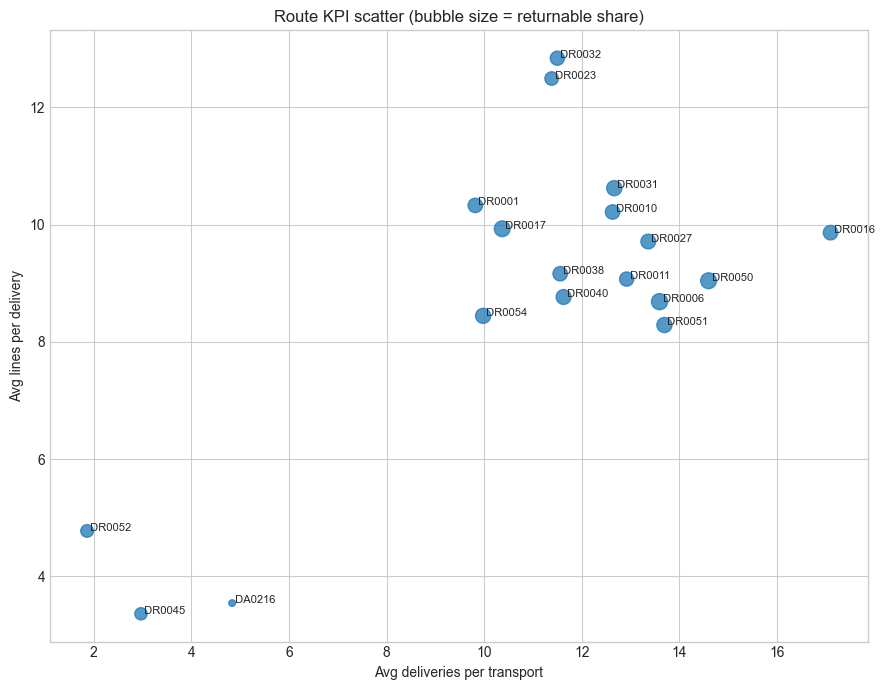

Top pilot candidates by complexity index:


,Ruta,avg_deliveries_per_transport,avg_lines_per_delivery,returnable_share,complexity
5,DR0016,17.100000,9.861111,0.314490,221.655880
10,DR0032,11.500000,12.836439,0.297881,191.591902
14,DR0050,14.600000,9.041096,0.385461,182.880853
9,DR0031,12.666667,10.620301,0.347601,181.284450
7,DR0023,11.382979,12.489720,0.266434,180.049244
8,DR0027,13.363636,9.709751,0.328388,172.368451
3,DR0010,12.632653,10.213247,0.311267,169.180198
2,DR0006,13.595238,8.684764,0.401211,165.442988
15,DR0051,13.694915,8.285891,0.346077,152.745468
4,DR0011,12.921053,9.069246,0.300273,152.371465


Interpretation: routes in upper-right with large bubbles are high-impact pilot candidates.


In [ ]:
route_kpi = (
    stop_df.groupby("Ruta")
    .agg(
        deliveries=("Entrega", "count"),
        transports=("Transporte", "nunique"),
        avg_lines_per_delivery=("line_count", "mean"),
        returnable_share=("returnable_share", "mean"),
    )
    .reset_index()
)
route_kpi["avg_deliveries_per_transport"] = route_kpi["deliveries"] / route_kpi["transports"]

fig, ax = plt.subplots(figsize=(9, 7))
sizes = 300 * (route_kpi["returnable_share"].fillna(0.01) + 0.05)
ax.scatter(
    route_kpi["avg_deliveries_per_transport"],
    route_kpi["avg_lines_per_delivery"],
    s=sizes,
    alpha=0.75,
)
for _, r in route_kpi.iterrows():
    ax.text(r["avg_deliveries_per_transport"], r["avg_lines_per_delivery"], f" {r['Ruta']}", fontsize=8)

ax.set_title("Route KPI scatter (bubble size = returnable share)")
ax.set_xlabel("Avg deliveries per transport")
ax.set_ylabel("Avg lines per delivery")
plt.tight_layout()
plt.show()

pilot_candidates = route_kpi.assign(
    complexity=lambda d: d["avg_deliveries_per_transport"] * d["avg_lines_per_delivery"] * (1 + d["returnable_share"])
).sort_values("complexity", ascending=False)

print("Top pilot candidates by complexity index:")
display(pilot_candidates[["Ruta", "avg_deliveries_per_transport", "avg_lines_per_delivery", "returnable_share", "complexity"]].head(10))
print("Interpretation: routes in upper-right with large bubbles are high-impact pilot candidates.")

## Validation and interpretation notes

- Geocode and schedule joins are imperfect; always read coverage outputs before comparing routes.
- Sequence-related charts rely on row-order-as-stop-order assumption.
- Handling cost in Pareto chart is a proxy using aisle-bucket spread and stop position weighting.
- Difficulty score is intentionally heuristic and should guide prioritization, not serve as ground truth.
- Recommended workflow:
  1. Select candidate routes from compactness + KPI scatter.
  2. Check friction using jump-distance chart.
  3. Review difficult stops and SKU co-occurrence for loading/picking redesign.
  4. Validate feasibility with load profile and time-window pressure.
  5. Compare candidate sequencing policies through Pareto trade-off chart.